In [1]:
# Basic Libraries
import pandas as pd
import numpy as np
import re
import string

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0   # Fake = 0
true["label"] = 1   # Real = 1

data = pd.concat([fake, true])
data = data.sample(frac=1).reset_index(drop=True)  # Shuffle dataset

data.head()


,title,text,subject,date,label
0,HILLARY CLINTON CRONYISM VIOLATES FEDERAL RULE...,Former Secretary of State Hillary Clinton soug...,politics,"Oct 6, 2016",0
1,Missouri Senate Republicans pass anti-gay reli...,CHICAGO (Reuters) - A 39-hour Democratic filib...,politicsNews,"March 9, 2016",1
2,Anti-Abortion Republican Cheated And Tried To...,A text message which was sent in January to U....,News,"October 3, 2017",0
3,Russia to help Syria rebuild energy facilities...,OSCOW (Reuters) - Russia will be the only cou...,worldnews,"December 18, 2017",1
4,Egypt's Sisi to meet Lebanon's Hariri on Tuesd...,CAIRO (Reuters) - Egyptian President Abdel Fat...,worldnews,"November 20, 2017",1


In [3]:
data.info()
data["label"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


label
0    23481
1    21417
Name: count, dtype: int64

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text


In [5]:
data["text"] = data["text"].apply(clean_text)


In [6]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [7]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [8]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.984053452115813

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      5936
           1       0.98      0.98      0.98      5289

    accuracy                           0.98     11225
   macro avg       0.98      0.98      0.98     11225
weighted avg       0.98      0.98      0.98     11225



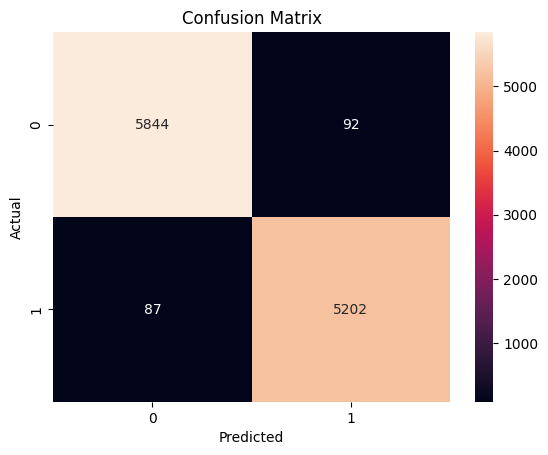

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [11]:
def predict_news(news):
    news = clean_text(news)
    news_vec = vectorizer.transform([news])
    prediction = model.predict(news_vec)
    
    if prediction[0] == 1:
        return "REAL NEWS"
    else:
        return "FAKE NEWS"


In [12]:
news_input = input("Enter News Text: ")
print("Prediction:", predict_news(news_input))


Enter News Text:  The Government of India announced a new national education policy aimed at improving digital learning infrastructure across rural schools starting next academic year.


Prediction: REAL NEWS


In [13]:
news_input = "Doctors reveal that eating only chocolate for 30 days can permanently cure all diseases."
print("Prediction:", predict_news(news_input))

Prediction: FAKE NEWS


In [14]:
import pickle

pickle.dump(model, open("fake_news_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))
